# Annotation Analysis: Clean Girl vs. Messy Girl

## Overview
This notebook analyzes the manual annotation goldstandard of 120 Pinterest pins (60 Clean Girl, 60 Messy Girl).

The analysis covers:
Inter-Annotator Agreement

* Descriptive Statistics per Category
* Comparison Clean Girl vs. Messy Girl
* Body Image Analysis (body_size, skin_color)
* Product Analysis (product_present, product_type)

## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import json

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Inter-Annotator Agreement (IAA)

Calculate Fleiss' Kappa for the original file with all annotations from 3 separate annotators.

In [ ]:
!pip install -q statsmodels

In [ ]:
# Load Original annotation data from "Archiv" sheet
df_original = pd.read_excel(
    '/content/drive/MyDrive/Team Dattel/Computational Social Media Analysis/alt_mitArchiv_Goldstandard.xlsx',
    sheet_name='Archiv'
)

# Extract trend from Image path
df_original['trend'] = df_original['Image'].str.extract(r'(clean_girl_|messy_girl_)')[0].str.replace('_', '')

print(f"Total annotations: {len(df_original)}")
print(f"Unique pins: {df_original['pin_id'].nunique()}")

Total annotations: 360
Unique pins: 120


In [ ]:
from statsmodels.stats.inter_rater import fleiss_kappa

def compute_fleiss(df, pin_ids, column):
    subset = df[df['pin_id'].isin(pin_ids)][['pin_id', column]].copy()

    # Treat NaN as "Missing" category instead of dropping
    subset[column] = subset[column].fillna('Missing')

    # Convert to matrix: rows = pins, cols = categories
    pivot = subset.pivot_table(index='pin_id', columns=column, aggfunc='size', fill_value=0)

    if pivot.shape[0] < 2:
        return None

    try:
        kappa = fleiss_kappa(pivot.values, method='fleiss')
        return kappa
    except Exception as e:
        print(f"  Error: {e}")
        return None

# Berechne multi_pins
annotation_counts = df_original['pin_id'].value_counts()
multi_pins = annotation_counts[annotation_counts == 3].index.tolist()

print(f"Pins mit 3 Annotationen: {len(multi_pins)}")

# Compute IAA für alle Kategorien
print("\nInter-Annotator Agreement (Fleiss' Kappa)")
iaa_results = {}
for col in ['body_size', 'gender', 'hair', 'person_present', 'product_present', 'skin_color']:
    kappa = compute_fleiss(df_original, multi_pins, col)
    iaa_results[col] = kappa
    if kappa is not None:
        print(f"{col}: κ = {kappa:.3f}")
    else:
        print(f"{col}: insufficient data")

# Summary DataFrame
iaa_df = pd.DataFrame(list(iaa_results.items()), columns=['Category', 'Fleiss Kappa'])
iaa_df

Pins mit 3 Annotationen: 120

Inter-Annotator Agreement (Fleiss' Kappa)
body_size: κ = 0.546
gender: κ = 0.755
hair: κ = 0.676
person_present: κ = 0.866
product_present: κ = 0.900
skin_color: κ = 0.612


,Category,Fleiss Kappa
0,body_size,0.546089
1,gender,0.754735
2,hair,0.676444
3,person_present,0.865563
4,product_present,0.899964
5,skin_color,0.612494


## 3. Load gold standard and parse JSON Fields

Some columns store choices as JSON strings. We need to parse them into lists.

In [ ]:
# Load annotation data
df_gold = pd.read_excel('/content/drive/MyDrive/Team Dattel/Computational Social Media Analysis/ohne_Archiv_Goldstandard.xlsx')

# Extract trend
df_gold['trend'] = df_gold['Image'].str.extract(r'(clean_girl_|messy_girl_)')[0].str.replace('_', '')

print(f"Total annotations: {len(df_gold)}")
print(f"Unique pins: {df_gold['pin_id'].nunique()}")

df_gold.head()

Total annotations: 120
Unique pins: 120


,Image,annotation_id,annotator,background_scene,body_size,clothing,created_at,gender,hair,id,lead_time,person_present,pin_id,product_present,product_type,skin_color,updated_at,trend
0,gs://ws2223-labelstudio/messy_girl_/4011087181...,35170,42,"{""choices"":[""Outdoor"",""Day"",""Candid""]}",Skinny,"{""choices"":[""Jewelry"",""Normal Clothes""]}",2026-02-02 12:18:01.128000,Female,Disheveled,279540,22498,Yes,4011087181366587,No,NaN,Light,2026-02-02 12:18:01.128000,messygirl
1,gs://ws2223-labelstudio/clean_girl_/2814818512...,34938,46,"{""choices"":[""Indoor"",""Day"",""Organized"",""Posed""]}",Skinny,"{""choices"":[""Athleisure"",""Loungewear""]}",2026-01-30 15:09:13.488000,Female,Natural,279541,141806,Yes,2814818512754916,Yes,"{""choices"":[""Beauty Product"",""Non alcoholic Be...",Not Sure,2026-01-30 15:09:13.488000,cleangirl
2,gs://ws2223-labelstudio/messy_girl_/3314374725...,34943,46,"{""choices"":[""Indoor"",""Messy"",""Candid""]}",Skinny,"{""choices"":[""Jewelry"",""Normal Clothes""]}",2026-01-30 15:11:54.927000,Female,Natural,279542,64629,Yes,33143747255770805,Yes,Beauty Product,Light,2026-01-30 15:11:54.927000,messygirl
3,gs://ws2223-labelstudio/clean_girl_/1351086762...,34948,46,"{""choices"":[""Indoor"",""Minimal"",""Posed""]}",Skinny,Normal Clothes,2026-01-30 15:16:21.643000,Female,Not Sure,279543,7455,Yes,13510867627993971,Yes,Beauty Product,Medium,2026-01-30 15:16:21.643000,cleangirl
4,gs://ws2223-labelstudio/clean_girl_/2617724158...,35002,42,"{""choices"":[""Outdoor"",""Day"",""Organized"",""Minim...",Not Sure,Not sure,2026-01-30 17:49:13.928000,Not Sure,Not Sure,279544,22451,No,26177241580823952,Yes,Books,Not Sure,2026-01-30 17:49:13.928000,cleangirl


In [ ]:
def parse_choices(val):
    if pd.isna(val):
        return None
    if isinstance(val, str) and val.startswith('{"choices":'):
        try:
            parsed = json.loads(val)
            return parsed['choices']
        except:
            return val
    return val

# Parse multi-choice fields
for col in ['background_scene', 'clothing', 'product_type']:
    df_gold[col + '_parsed'] = df_gold[col].apply(parse_choices)

# Check result
print("Example parsed background_scene:")
print(df_gold['background_scene_parsed'].head(3).tolist())

Example parsed background_scene:
[['Outdoor', 'Day', 'Candid'], ['Indoor', 'Day', 'Organized', 'Posed'], ['Indoor', 'Messy', 'Candid']]


## 5. Descriptive overall statistics

Distribution of each category across all 120 pins.

In [ ]:
# Person present
print("Person Present")
print(df_gold['person_present'].value_counts(dropna=False))
print(f"Percentage with person: {(df_gold['person_present'] == 'Yes').mean():.1%}")

Person Present
person_present
Yes    104
No      16
Name: count, dtype: int64
Percentage with person: 86.7%


In [ ]:
# Gender
print("Gender")
print(df_gold['gender'].value_counts(dropna=False))
print(f"\nFemale representation: {(df_gold['gender'] == 'Female').sum() / df_gold['gender'].notna().sum():.1%}")

Gender
gender
Female      99
NaN         16
Not Sure     4
Mixed        1
Name: count, dtype: int64

Female representation: 95.2%


Body Size
body_size
Skinny      68
Not Sure    32
NaN         15
Average      5
Name: count, dtype: int64


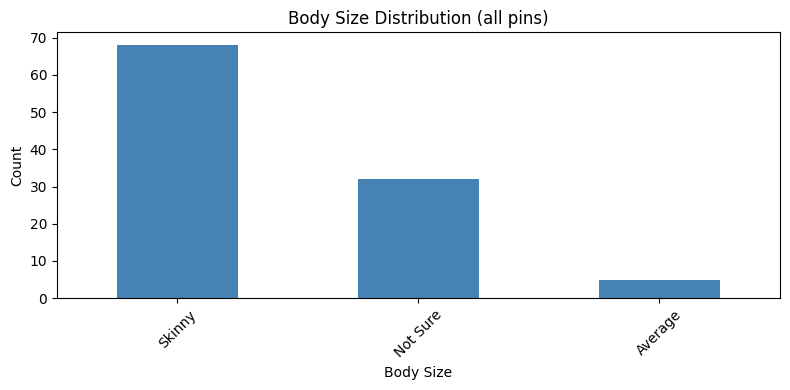

In [ ]:
# Body size
print("Body Size")
print(df_gold['body_size'].value_counts(dropna=False))

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
df_gold['body_size'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Body Size Distribution (all pins)')
ax.set_xlabel('Body Size')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Skin color
print("Skin Color")
print(df_gold['skin_color'].value_counts(dropna=False))
print(f"\nLight skin representation: {(df_gold['skin_color'] == 'Light').sum() / df_gold['skin_color'].notna().sum():.1%}")

Skin Color
skin_color
Light       92
NaN         15
Not Sure    10
Medium       3
Name: count, dtype: int64

Light skin representation: 87.6%


In [ ]:
# Hair
print("Hair")
print(df_gold['hair'].value_counts(dropna=False))

Hair
hair
Tidy          38
Natural       26
Not Sure      24
Disheveled    17
NaN           15
Name: count, dtype: int64


In [ ]:
# Product present
print("Product Present")
print(df_gold['product_present'].value_counts(dropna=False))
print(f"\nPercentage with product: {(df_gold['product_present'] == 'Yes').mean():.1%}")

Product Present
product_present
Yes         90
No          29
Not Sure     1
Name: count, dtype: int64

Percentage with product: 75.0%


## 6. Comparison: Clean Girl vs. Messy Girl

Body Size by Trend
body_size  Average  Not Sure  Skinny
trend                               
cleangirl      5.8      34.6    59.6
messygirl      3.8      26.4    69.8


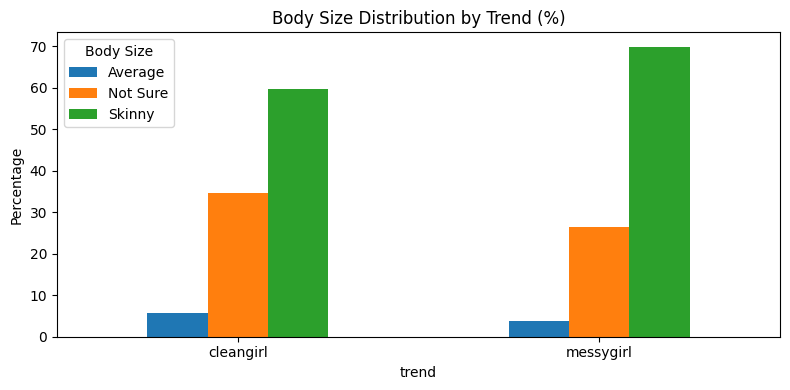

In [ ]:
# Body size by trend
print("Body Size by Trend")
ct = pd.crosstab(df_gold['trend'], df_gold['body_size'], normalize='index') * 100
print(ct.round(1))

ct.plot(kind='bar', figsize=(8, 4), title='Body Size Distribution by Trend (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Body Size')
plt.tight_layout()
plt.show()

In [ ]:
# Skin color by trend
print("Skin Color by Trend")
ct = pd.crosstab(df_gold['trend'], df_gold['skin_color'], normalize='index') * 100
print(ct.round(1))

Skin Color by Trend
skin_color  Light  Medium  Not Sure
trend                              
cleangirl    84.6     3.8      11.5
messygirl    90.6     1.9       7.5


Hair by Trend
hair       Disheveled  Natural  Not Sure  Tidy
trend                                         
cleangirl         0.0     15.4      28.8  55.8
messygirl        32.1     34.0      17.0  17.0


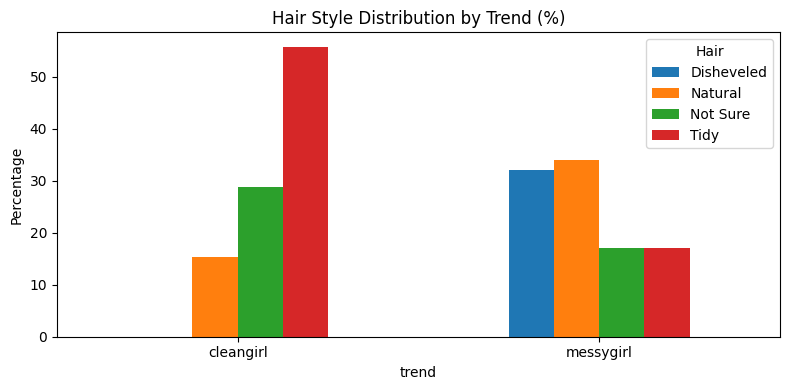

In [ ]:
# Hair by trend
print("Hair by Trend")
ct = pd.crosstab(df_gold['trend'], df_gold['hair'], normalize='index') * 100
print(ct.round(1))

ct.plot(kind='bar', figsize=(8, 4), title='Hair Style Distribution by Trend (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Hair')
plt.tight_layout()
plt.show()

In [ ]:
# Product present by trend
print("Product Present by Trend")
ct = pd.crosstab(df_gold['trend'], df_gold['product_present'], normalize='index') * 100
print(ct.round(1))

Product Present by Trend
product_present    No  Not Sure   Yes
trend                                
cleangirl        14.5       0.0  85.5
messygirl        34.5       1.7  63.8


## 7. Background Scene Analysis

Background_scene is multi-select — we need to explode the lists.

In [ ]:
# Explode background_scene lists
bg_exploded = df_gold[['pin_id', 'trend', 'background_scene_parsed']].copy()
bg_exploded = bg_exploded[bg_exploded['background_scene_parsed'].notna()]
bg_exploded = bg_exploded.explode('background_scene_parsed')

print("Top background scene tags:")
print(bg_exploded['background_scene_parsed'].value_counts().head(10))

# By trend
print("\nBackground Scene by Trend")
ct = pd.crosstab(bg_exploded['trend'], bg_exploded['background_scene_parsed'], normalize='index') * 100
print(ct.round(1))

Top background scene tags:
background_scene_parsed
Indoor       90
Minimal      74
Posed        73
Organized    62
Day          61
Candid       45
Night        37
Messy        27
Maximal      24
Outdoor      22
Name: count, dtype: int64

Background Scene by Trend
background_scene_parsed  Candid   Day  Indoor  Maximal  Messy  Minimal  Night  \
trend                                                                           
cleangirl                   3.4  13.8    17.5      1.5    1.5     18.3    3.4   
messygirl                  14.5   9.6    17.3      8.0    9.2     10.0   11.2   

background_scene_parsed  Not Sure  Organized  Outdoor  Posed  
trend                                                         
cleangirl                     0.7       18.3      2.6   19.0  
messygirl                     0.0        5.2      6.0    8.8  


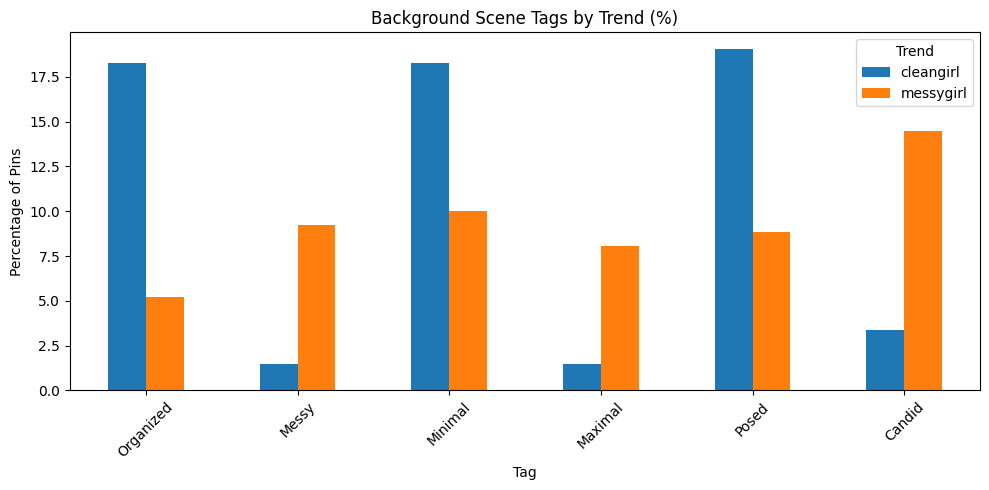

In [ ]:
# Visualize key differences
key_tags = ['Organized', 'Messy', 'Minimal', 'Maximal', 'Posed', 'Candid']
ct_subset = ct[key_tags]

ct_subset.T.plot(kind='bar', figsize=(10, 5), title='Background Scene Tags by Trend (%)')
plt.ylabel('Percentage of Pins')
plt.xlabel('Tag')
plt.xticks(rotation=45)
plt.legend(title='Trend')
plt.tight_layout()
plt.show()

## 8. Product Type Analysis

In [ ]:
# Explode product_type lists
prod_exploded = df_gold[['pin_id', 'trend', 'product_type_parsed']].copy()
prod_exploded = prod_exploded[prod_exploded['product_type_parsed'].notna()]
prod_exploded = prod_exploded.explode('product_type_parsed')

print("Product types:")
print(prod_exploded['product_type_parsed'].value_counts())

# By trend
print("\nProduct Type by Trend")
ct = pd.crosstab(prod_exploded['trend'], prod_exploded['product_type_parsed'])
print(ct)

Product types:
product_type_parsed
Beauty Product                                         52
Electronics (Laptop, Headphones, Camera, Mobile...)    36
Non alcoholic Beverages                                23
Books                                                  20
Drugs or Intoxicants                                   14
Candles                                                 9
Healthy Food                                            8
Sport Equipment                                         6
Plants                                                  6
Unhealthy Food                                          2
Not Sure                                                1
Name: count, dtype: int64

Product Type by Trend
product_type_parsed  Beauty Product  Books  Candles  Drugs or Intoxicants  \
trend                                                                       
cleangirl                        34     13        6                     1   
messygirl                        18      7     

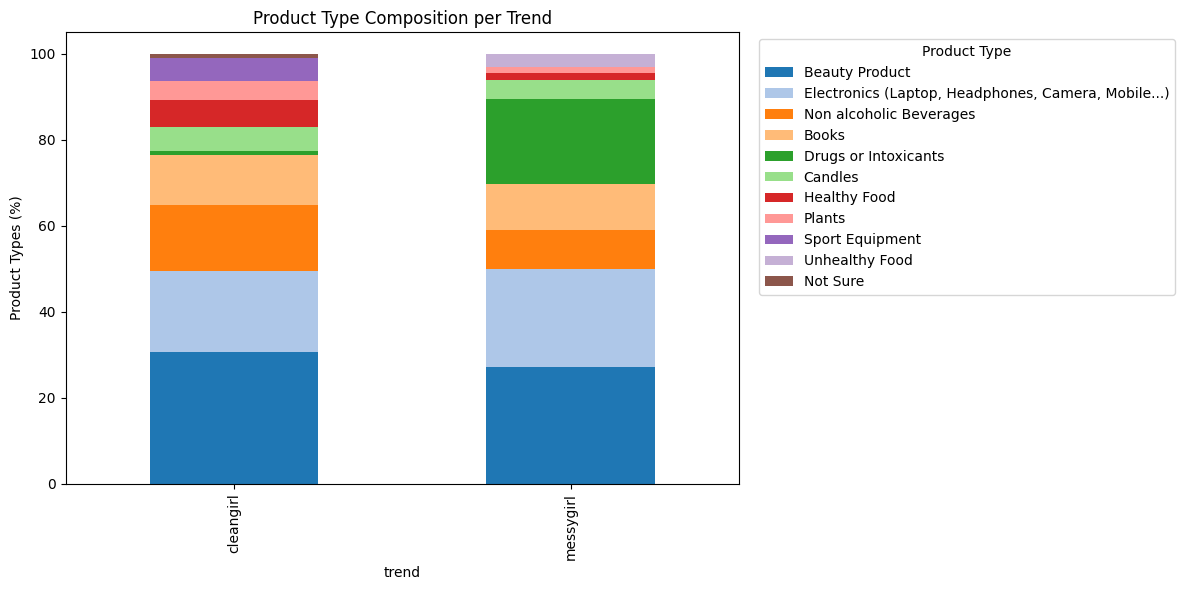

In [ ]:
# overview of product_type list per trend
base_colors = plt.cm.tab20.colors

ordered_product_types = ct.sum(axis=0).sort_values(ascending=False).index

ct = ct[ordered_product_types]
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100


color_map = dict(zip(ct_pct.columns, base_colors))

color_map["unhealthy food"] = "#d62728"
color_map["beauty product"] = "#9467bd"

ct_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=[color_map[c] for c in ct_pct.columns]
)

plt.ylabel("Product Types (%)")
plt.title("Product Type Composition per Trend")
plt.legend(title="Product Type", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## 9. Export Summary Statistics

In [ ]:
# Save IAA results
iaa_df.to_csv('/content/drive/MyDrive/Team Dattel/Computational Social Media Analysis/IAA_Results.csv', index=False)
print("Saved IAA results")

Saved IAA results
